# P1 · 04 — ARIMA & SARIMA: the Box-Jenkins method

ARIMA models the **autocorrelation structure** of a stationarised series:

* **AR(p)** — regress on the last $p$ values,
* **I(d)** — difference $d$ times to remove trend,
* **MA(q)** — regress on the last $q$ forecast errors.

**SARIMA** adds a seasonal triple $(P,D,Q)_m$. From notebook 01 we diagnosed
**d = 1, D = 1, m = 4**. The Box-Jenkins loop: *identify → estimate → diagnose →
forecast.*

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from src import baselines as B, backtest as bt, classical as C

annual = data.load_annual(); q = data.load_quarterly()
la = np.log(annual); nsa = q["gdp_nsa"]

### Warm-up: plain ARIMA on annual log-GDP (no seasonality)

Annual GDP has no seasonal cycle, so a non-seasonal ARIMA(1,1,1) on the log is a
clean first model. We read the summary (coefficients, AIC) and forecast with a
**prediction interval**.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9987      0.005    199.876      0.000       0.989       1.009
ma.L1         -0.9191      0.102     -8.974      0.000      -1.120      -0.718
sigma2         0.0010      0.000      6.738      0.000       0.001       0.001


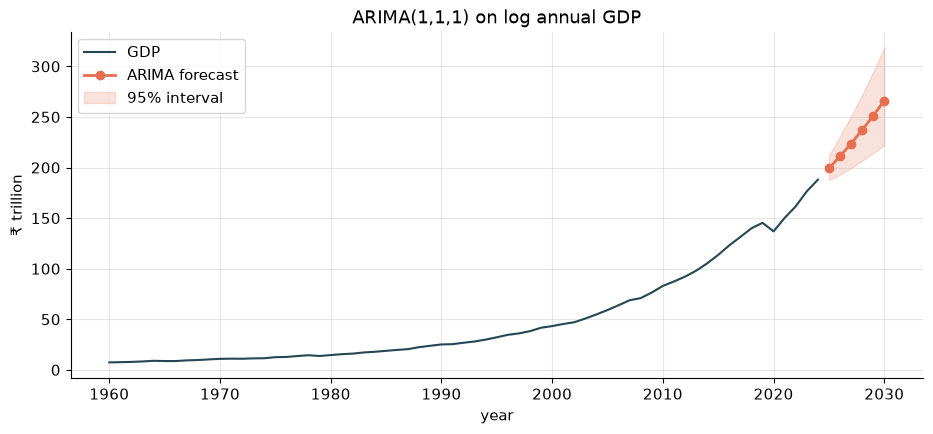

In [2]:
m = ARIMA(la.values, order=(1, 1, 1)).fit()
print(m.summary().tables[1])
H = 6
fcres = m.get_forecast(H)
mean = np.exp(fcres.predicted_mean)
ci = np.exp(fcres.conf_int(alpha=0.05))
yrs = np.arange(annual.index.max() + 1, annual.index.max() + 1 + H)

fig, ax = plt.subplots()
ax.plot(annual.index, annual.values / 1e12, color="#264653", label="GDP")
ax.plot(yrs, mean / 1e12, color="#e76f51", lw=2, marker="o", label="ARIMA forecast")
ax.fill_between(yrs, ci[:, 0] / 1e12, ci[:, 1] / 1e12, color="#e76f51",
                alpha=0.2, label="95% interval")
ax.set(title="ARIMA(1,1,1) on log annual GDP", xlabel="year",
       ylabel="₹ trillion"); ax.legend(); plt.show()

### Diagnose the residuals (this is the step people skip)

If the model captured the structure, the residuals should be **white noise** — no
autocorrelation, roughly normal. The **Ljung-Box** test's null is "residuals are
independent"; we *want* a high p-value. `plot_diagnostics` shows the standardized
residuals, histogram, Q-Q plot, and residual ACF.

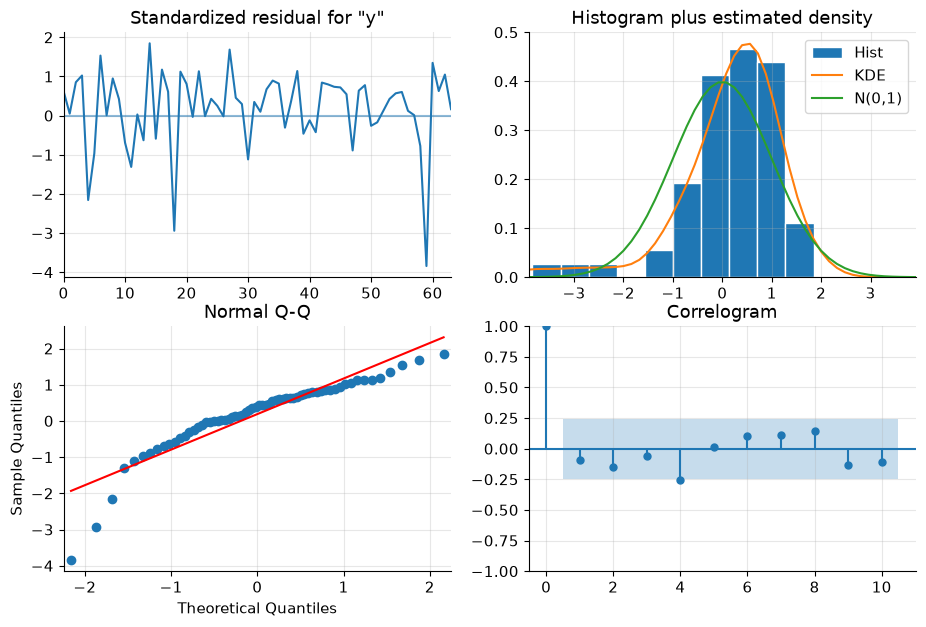

Ljung-Box (lag 8):  p = 0.203  -> residuals look like white noise


In [3]:
fig = m.plot_diagnostics(figsize=(11, 7)); plt.show()
lb = acorr_ljungbox(m.resid[1:], lags=[8], return_df=True)
print("Ljung-Box (lag 8):  p =", round(float(lb['lb_pvalue'].iloc[0]), 3),
      " -> residuals look like white noise" if float(lb['lb_pvalue'].iloc[0]) > 0.05
      else " -> structure remains!")

### SARIMA on quarterly NSA: let AIC pick the orders

Rather than agonise over the ACF/PACF, we fix d/D from the stationarity analysis
and grid-search the AR/MA orders, choosing the lowest **AIC** (the hand-rolled
version of `auto_arima`). `src/classical.grid_search_sarima` does exactly this.

In [4]:
grid = C.grid_search_sarima(nsa, d=1, D=1, m=4, max_pq=2, max_PQ=1)
print("Top 5 by AIC:")
print(grid.head(5).to_string())
best = grid.iloc[0]
print("\nBest:", best['order'], best['seasonal_order'], "AIC", round(best['AIC'], 1))

Top 5 by AIC:
       order seasonal_order         AIC         BIC
0  (1, 1, 1)   (0, 1, 0, 4) -266.253944 -259.070596
1  (2, 1, 1)   (0, 1, 0, 4) -264.437238 -254.859441
2  (1, 1, 2)   (0, 1, 0, 4) -260.477065 -250.948959
3  (0, 1, 1)   (1, 1, 1, 4) -259.877056 -250.501834
4  (0, 1, 2)   (0, 1, 0, 4) -259.594316 -252.448237

Best: (1, 1, 1) (0, 1, 0, 4) AIC -266.3


The winner is typically **SARIMA(1,1,1)(0,1,0)₄** — note the seasonal AR/MA are
zero: the seasonal *difference* (D=1) already absorbs the seasonality, leaving the
regular (1,1,1) to model the rest. Parsimony wins on short series. Let's fit it,
diagnose, and forecast 8 quarters with an interval.

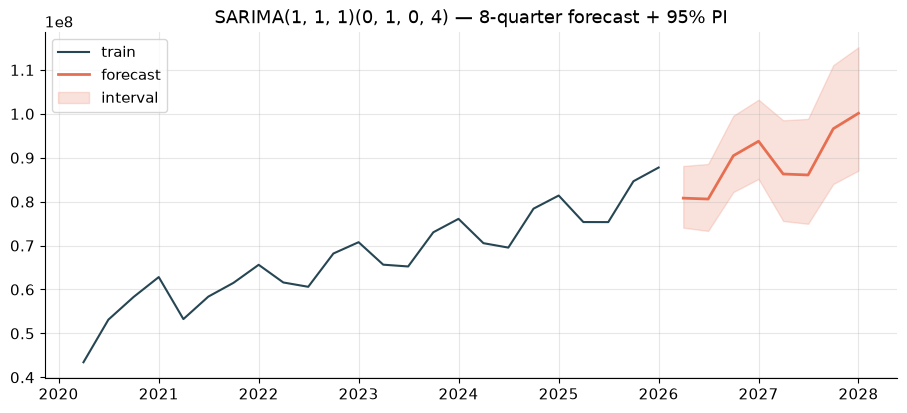

2026Q2     80799934.0
2026Q3     80598219.0
2026Q4     90463970.0
2027Q1     93762101.0
2027Q2     86300639.0
2027Q3     86079173.0
2027Q4     96613023.0
2028Q1    100134128.0
Freq: Q-DEC, dtype: float64


In [5]:
order, sorder = best['order'], best['seasonal_order']
mean, lo, hi = C.sarima_forecast_pi(nsa, 8, order=order, seasonal_order=sorder)
future = pd.period_range(nsa.index.max() + 1, periods=8, freq="Q")
fc = pd.Series(mean, index=future)
lo = pd.Series(lo, index=future); hi = pd.Series(hi, index=future)

fig, ax = plt.subplots()
plots.plot_forecast(nsa.iloc[-24:], pred=fc, lower=lo, upper=hi,
                    title=f"SARIMA{order}{sorder} — 8-quarter forecast + 95% PI", ax=ax)
plt.show()
print(fc.round(0))

Notice the interval **widens with horizon** and is **asymmetric** in levels (wider
on the upside) — a direct consequence of forecasting in log space. That asymmetry
is *correct* for a multiplicative process and is something naive symmetric
intervals get wrong.

### Final head-to-head: baselines vs ETS vs SARIMA

In [6]:
fcs = {
    "seasonal_naive(4)": B.seasonal_naive(4),
    "drift": B.drift,
    "Holt-Winters": C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4),
    f"SARIMA{order}{sorder}": C.sarima_forecaster(order, sorder),
    "SARIMA(1,1,1)(1,1,1)4": C.sarima_forecaster((1, 1, 1), (1, 1, 1, 4)),
}
bt.compare(nsa, fcs, initial=40, h=4, step=1, season_length=4).round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
"SARIMA(1, 1, 1)(0, 1, 0, 4)",2004034.387,4178715.528,3.693,3.763,0.612
Holt-Winters,2097819.195,3929438.519,3.809,3.771,0.640
"SARIMA(1,1,1)(1,1,1)4",2269733.322,4586218.524,4.128,4.253,0.693
drift,3322822.364,4827551.462,5.627,5.591,1.014
seasonal_naive(4),4138715.808,4655608.591,7.221,7.392,1.263


Both ETS-HW and SARIMA land well under **MASE 0.7**. On *this* short series the
two are close; Holt-Winters often edges it because SARIMA has more parameters to
estimate from few points (the bias–variance trade-off in miniature). The
disciplined answer to "which model?" is never dogma — it's **whatever wins the
backtest**, which is exactly what notebook 05 formalises.

---
**Next (05):** capstone — turn this into a repeatable forecasting *decision* and a
forecast you'd actually defend in a meeting.